# CIS 2450 Final Project. US Traffic Accident Severity Prediction

**Authors:** Erk & Brian

## Question
Given that an accident has occurred, will it be **severe** based on weather, road features, and time of day?

## Why binary classification?
We predict **Severe (Severity 3–4) vs. Not Severe (Severity 1–2)**. Adjacent severity classes share nearly identical feature distributions — the distinction is driven by response times and injury counts that are outside our dataset. Binary classification gives our models a learnable signal and directly serves the use case: flagging high-risk conditions for city planners.

## Table of Contents
1. Setup & data loading
2. Data cleaning
3. Exploratory Data Analysis
4. Modeling setup & why binary classification
5. Model 1: Binary Logistic Regression (baseline)
6. Model 2: Binary Random Forest
7. Model 3: Binary Gradient Boosting
8. Model comparison & conclusions


---
# 1. Setup & Data Loading

We use Polars for the initial CSV load because it's much faster. Then, we then convert to pandas for EDA and modeling because seaborn/scikit-learn integrate more cleanly with pandas.

> **Note on the data:** the raw Kaggle dataset is massive (3 GB) and is heavily imbalanced. Severity 2 makes up nearly ALL of records. To give every class roughly equal representation we constructed a stratified sample using `scripts/balance_dataset.py`, which takes all 67,366 Severity 1 records and randomly samples an equal number from each of Severities 2, 3, and 4.
>
> **Pipeline note:** the balancing script ran on the *full* dataset before any train/test split. This is a pipeline violation — the test set's class distribution was shaped by the same sampling step that created training data. We correct for this in Section 4 by re-downsampling *only* the training partition after splitting, so the test set is never touched by the balancing logic.


In [68]:
import polars as pl

df = pl.read_csv("../data/raw/accidentsData.csv", truncate_ragged_lines=True)


In [69]:
# Check the basic info of the dataset (number of entries, column data types)
print(f"Shape: {df.shape}")
print("\nSchema:")
print(df.schema)

Shape: (269464, 46)

Schema:
Schema({'ID': String, 'Source': String, 'Severity': Int64, 'Start_Time': String, 'End_Time': String, 'Start_Lat': Float64, 'Start_Lng': Float64, 'End_Lat': String, 'End_Lng': String, 'Distance(mi)': Float64, 'Description': String, 'Street': String, 'City': String, 'County': String, 'State': String, 'Zipcode': String, 'Country': String, 'Timezone': String, 'Airport_Code': String, 'Weather_Timestamp': String, 'Temperature(F)': Float64, 'Wind_Chill(F)': Float64, 'Humidity(%)': Float64, 'Pressure(in)': Float64, 'Visibility(mi)': Float64, 'Wind_Direction': String, 'Wind_Speed(mph)': Float64, 'Precipitation(in)': Float64, 'Weather_Condition': String, 'Amenity': Boolean, 'Bump': Boolean, 'Crossing': Boolean, 'Give_Way': Boolean, 'Junction': Boolean, 'No_Exit': Boolean, 'Railway': Boolean, 'Roundabout': Boolean, 'Station': Boolean, 'Stop': Boolean, 'Traffic_Calming': Boolean, 'Traffic_Signal': Boolean, 'Turning_Loop': Boolean, 'Sunrise_Sunset': String, 'Civil_Twili

---
# 2. Data Cleaning

The raw dataset has many columns we don't need and rows with missing values in some columns. So, we drop nulls only in the columns we actually plan to use as features. dropping all row with a single null would throw away most of our data because some columns (like End_Lat, Wind_Chill, Precipitation) have very high null rates that we'd rather just ignore.


In [70]:
df = pl.read_csv("../data/raw/accidentsData.csv", has_header=True, truncate_ragged_lines=True)

# Polars will name the columns column_1, column_2, etc.
# Let's see the first few rows to figure out which columns are which
display(df.head(3))

# 2. Example of dropping columns you don't need (we will need to update these names based on the output above)
# For example, if column_2 and column_3 are lat/long:
# df = df.drop(['column_2', 'column_3'])

# 3. Drop rows that have null (missing) values in the columns we care about
features_i_care_about = [
    "Severity", "Start_Time", "Temperature(F)", "Humidity(%)",
    "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)",
    "Weather_Condition", "Traffic_Signal", "Junction", "Crossing", 

]
df_cleaned = df.drop_nulls(subset=features_i_care_about)
print(f"Before: {df.shape}    After: {df_cleaned.shape}")

print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
str,str,i64,str,str,f64,f64,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,str,str
"""A-164""","""Source2""",1,"""2016-02-15 17:22:10""","""2016-02-15 18:07:10""",41.395805,-81.935562,null,null,0.0,"""Accident on Westlawn Dr at Hol…","""Maplehurst Rd""","""North Olmsted""","""Cuyahoga""","""OH""","""44070-5152""","""US""","""US/Eastern""","""KCLE""","""2016-02-15 17:51:00""",33.1,27.7,82.0,29.95,7.0,"""SSE""",5.8,null,"""Overcast""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Day""","""Day""","""Day""","""Day"""
"""A-375""","""Source2""",1,"""2016-02-24 07:59:51""","""2016-02-24 08:29:51""",40.018669,-81.565704,null,null,0.0,"""Accident on North Ave at Old B…","""Old Byesville Rd""","""Cambridge""","""Guernsey""","""OH""","""43725""","""US""","""US/Eastern""","""KZZV""","""2016-02-24 07:53:00""",46.0,40.6,86.0,29.46,7.0,"""East""",11.5,0.08,"""Light Rain""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Day""","""Day""","""Day""","""Day"""
"""A-961""","""Source2""",1,"""2016-06-22 23:54:48""","""2016-06-23 00:39:48""",37.750488,-121.379982,null,null,0.0,"""Accident on Banta Rd at Briche…","""W F St""","""Tracy""","""San Joaquin""","""CA""","""95304""","""US""","""US/Pacific""","""KSCK""","""2016-06-22 23:55:00""",66.0,null,42.0,29.94,10.0,"""WNW""",6.9,null,"""Clear""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Night""","""Night""","""Night""","""Night"""


Before: (269464, 46)    After: (246347, 46)

Original shape: (269464, 46)
Cleaned shape: (246347, 46)


**Quick note** 
Our first attempt, we dropped all nulls. In doing so, we lost nearly all our data. Now that we defined columns that we really care about, we can drop entries that have a null entry on one of them. We went from losing nearly all our data to only ~3k entries.


### 2.2 Outlier Treatment

Before modeling, we check for physically impossible values in numerical features. Sensor errors in weather data are common — equipment malfunctions can log impossible readings that would distort model training if left uncapped.

We cap rather than drop outlier rows because these rows still have valid values for every other feature. Dropping them would throw away real accident records unnecessarily.

In [71]:
# Check for physically impossible values in numerical features (sensor errors are common in weather data)
print("Numerical feature ranges after null dropping:")
for col in ['Wind_Speed(mph)', 'Visibility(mi)', 'Temperature(F)', 'Humidity(%)']:
    q99  = float(df_cleaned[col].quantile(0.99))
    vmax = float(df_cleaned[col].max())
    print(f"  {col:<22s}  max={vmax:>8.1f}   99th pct={q99:>6.1f}")

# Wind_Speed max of 822 mph is physically impossible — this is a sensor error.
# We cap at the 99th percentile to preserve all rows while removing the distortion.
ws_p99 = float(df_cleaned['Wind_Speed(mph)'].quantile(0.99))
df_cleaned = df_cleaned.with_columns(
    pl.col('Wind_Speed(mph)').clip(upper_bound=ws_p99)
)
print(f"\nWind_Speed capped at {ws_p99:.1f} mph (99th percentile)")
print(f"New max: {float(df_cleaned['Wind_Speed(mph)'].max()):.1f} mph")

Numerical feature ranges after null dropping:
  Wind_Speed(mph)         max=   822.8   99th pct=  23.0
  Visibility(mi)          max=    80.0   99th pct=  10.0
  Temperature(F)          max=   140.0   99th pct=  99.0
  Humidity(%)             max=   100.0   99th pct= 100.0



Wind_Speed capped at 23.0 mph (99th percentile)
New max: 23.0 mph


---
# 3. Exploratory Data Analysis (EDA)

We want to understand the data we are actually working with. The plots below cover:

1. The target variable (severity distribution)
2. Temporal patterns (hour and day of week)
3. Weather effects (top conditions and severity rates)
4. Numerical feature correlations
5. Road feature sparsity

Each plot tells us something we'll need to remember when modeling.


### 3.1 Convert to pandas and add time features

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # using pandas for seamless seaborn integration
import numpy as np

# Let's convert the cleaned Polars dataframe to a Pandas dataframe for easier plotting with Seaborn
# (Make sure the previous cell defining df_cleaned has been run)
pdf = df_cleaned.to_pandas()

# Convert Start_Time to datetime to extract useful features like Hour and Day of Week
pdf['Start_Time'] = pd.to_datetime(pdf['Start_Time'], errors='coerce')
pdf['Hour'] = pdf['Start_Time'].dt.hour
pdf['DayOfWeek'] = pdf['Start_Time'].dt.day_name()

print("Data ready for EDA.")

Data ready for EDA.


### 3.2 Distribution of accident severity

Our balancing script gave each severity class ~67k rows. After dropping nulls in our feature columns, the counts shifted slightly because different severity levels have different null rates. The chart below confirms the distribution is roughly flat (4 bars of similar height).

> **Why this matters:** if the data were imbalanced, models would cheat by always predicting the majority class. Balancing forces models to actually learn.


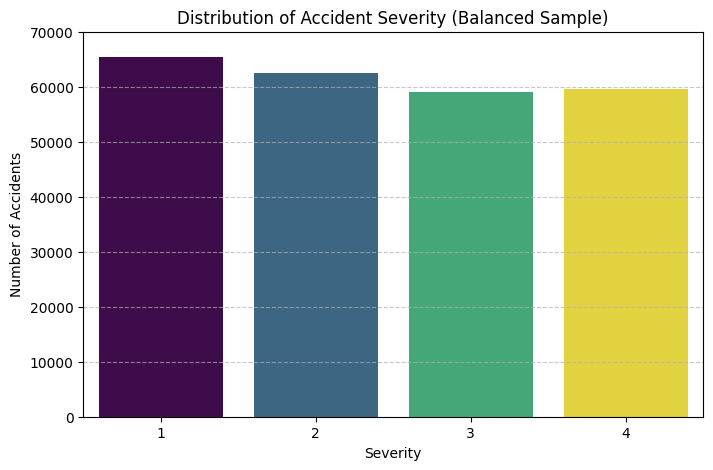

In [73]:
# Visual 1: Distribution of Accident Severity
plt.figure(figsize=(8, 5))
sns.countplot(data=pdf, x='Severity', hue='Severity', palette='viridis', legend=False)
plt.title('Distribution of Accident Severity (Balanced Sample)')
plt.xlabel('Severity')
plt.ylabel('Number of Accidents')
plt.ylim(0, 70000)  # start y-axis at 0 so visual differences match real differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

As we can see, the data is cleaned and is still roughly the same amount of entries which is exacly what we wanted

### 3.3 Accidents by hour of day

Time of day is one of our strongest predictors. We expect rush hour spikes: people commuting, more cars on the road, more accidents. We plot both *all accidents* and *severe-only accidents* to see if severe accidents follow the same pattern or if they peak at different times.


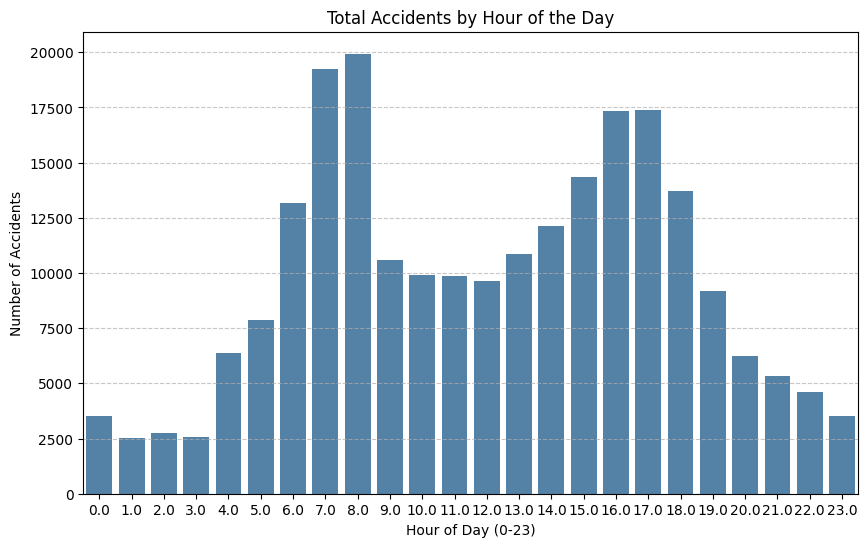

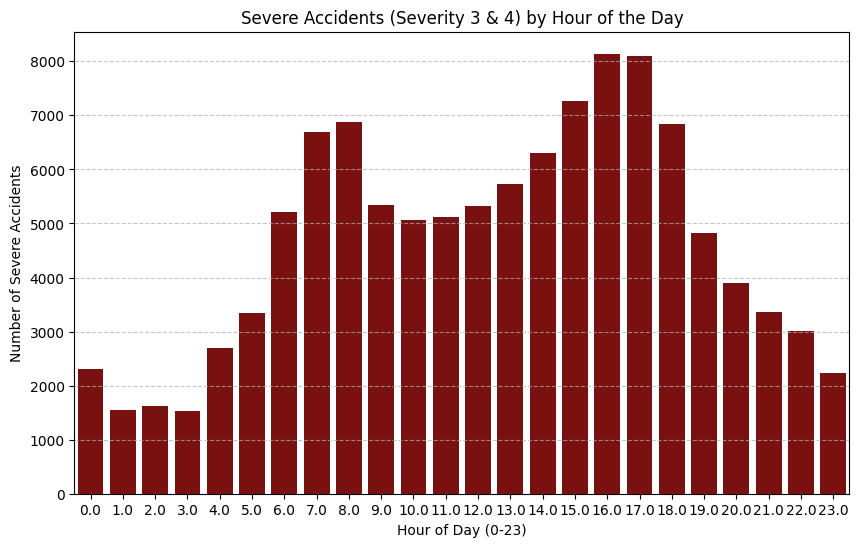

In [74]:
# Visual 2: Accidents by Hour of Day
plt.figure(figsize=(10, 6))
sns.countplot(data=pdf, x='Hour', color='steelblue')
plt.title('Total Accidents by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Let's also look at proportion of severe accidents (Severity 3 & 4) by hour
severe_df = pdf[pdf['Severity'] >= 3]
plt.figure(figsize=(10, 6))
sns.countplot(data=severe_df, x='Hour', color='darkred')
plt.title('Severe Accidents (Severity 3 & 4) by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Severe Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

It seems like severe accidents throughout the day are less throughout the morning and more during the evening, compared all of the accidents where there are a bit more in the morning and less in the evening.

### 3.4 Severity rate by weather condition

A more useful framing than "how many accidents happened in each weather" is "of accidents in this weather, what % are severe?" We have to account for the fact that fair weather has way more accidents simply because more people drive in fair weather.

We filter to weather conditions with at least 100 accidents to avoid noisy estimates from rare conditions.


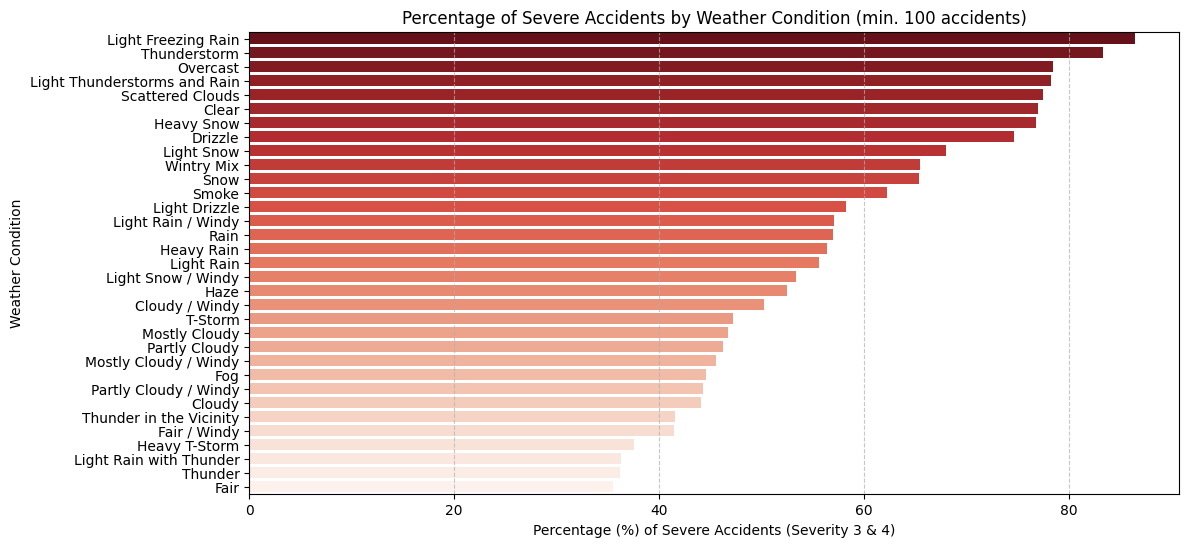

In [75]:
# Visual 4: Proportion of Severe Accidents by Weather Condition
# To avoid noisy data from rare weather events, we'll only look at weather conditions with at least 100 accidents in our cleaned dataset
weather_counts = pdf['Weather_Condition'].value_counts()
valid_weather = weather_counts[weather_counts >= 100].index

# Filter dataframe
weather_df = pdf[pdf['Weather_Condition'].isin(valid_weather)].copy()

# Create a binary flag for Severe (Severity 3 or 4)
weather_df['Is_Severe'] = (weather_df['Severity'] >= 3).astype(int)

# Calculate the percentage of severe accidents for each weather condition
severity_rate = weather_df.groupby('Weather_Condition')['Is_Severe'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=severity_rate.values, y=severity_rate.index, hue=severity_rate.index, palette='Reds_r', legend=False)
plt.title('Percentage of Severe Accidents by Weather Condition (min. 100 accidents)')
plt.xlabel('Percentage (%) of Severe Accidents (Severity 3 & 4)')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



This tells a much better story than just how many accidents happened in X weather. It shows which weather conditions are most likely to result in a severe accident, regardless of how common that weather is.

### 3.5 Correlation heatmap of numerical features

For linear models like Logistic Regression, multicollinearity (features that are highly correlated with each other) can cause problems because the model gets confused about which feature is doing the work. The heatmap below shows pairwise correlations among numerical weather features.


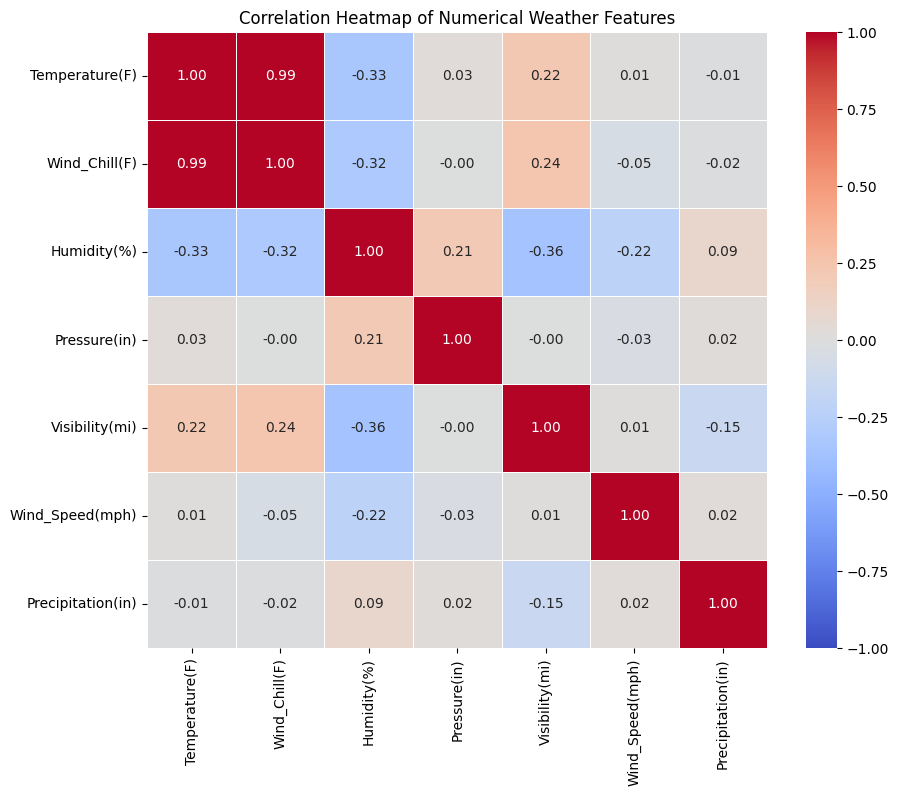

In [76]:
# Visual 5: Correlation Heatmap of Numerical Features
# This is crucial for Logistic Regression to check for multicollinearity (features that are highly correlated with each other)
num_cols = ['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

# Calculate correlation matrix
corr_matrix = pdf[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Weather Features')
plt.show()


For example, temp and wind chill are extremely correlated, so we should only pick 1 to not confuse our model

### 3.6 Accidents by day of week

Confirming the rush-hour hypothesis from another angle: If commuting drives most accidents, weekends should have fewer.


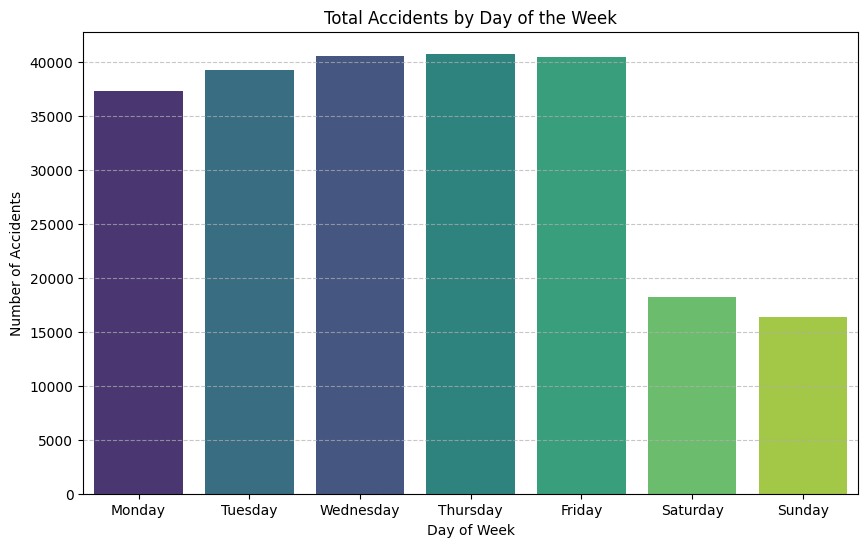

In [77]:
# Visual 6: Accidents by Day of Week
plt.figure(figsize=(10, 6))
# Ensure correct chronological ordering of days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=pdf, x='DayOfWeek', order=days_order, hue='DayOfWeek', palette='viridis', legend=False)
plt.title('Total Accidents by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Exactly what we thought.

### 3.7 Road feature sparsity

The dataset has 13 boolean columns describing road context (Crossing, Junction, Bump, etc.). Many of these are very rare, the chart below shows which ones are actually present often enough to be useful as features.


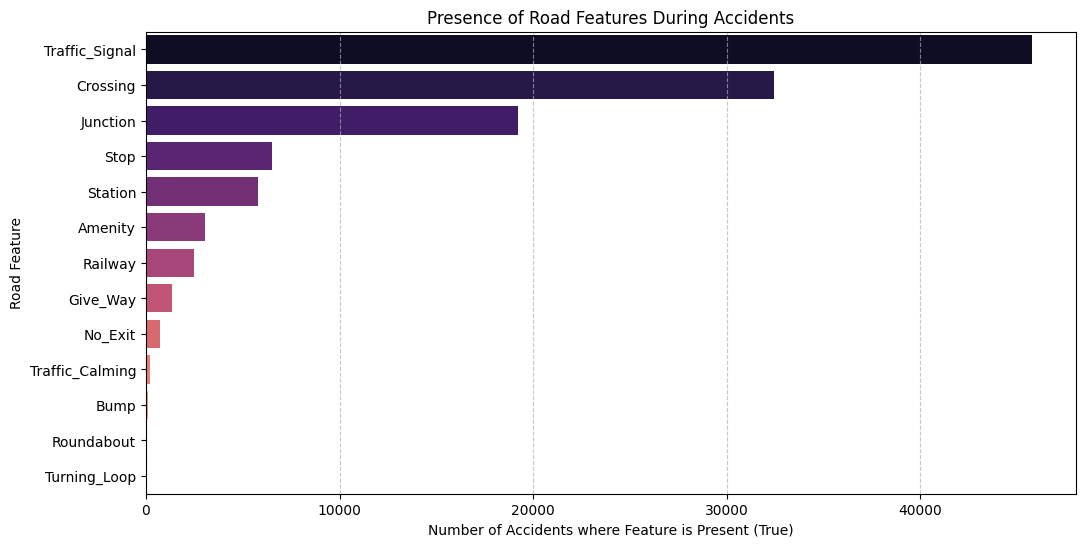

In [78]:
# Visual 7: Frequency of Boolean Road Features
# You mentioned these boolean flags as an anticipated obstacle due to sparsity.
bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

# Calculate the number of accidents where each road feature is present (True)
bool_counts = pdf[bool_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=bool_counts.values, y=bool_counts.index, hue=bool_counts.index, palette='magma', legend=False)
plt.title('Presence of Road Features During Accidents')
plt.xlabel('Number of Accidents where Feature is Present (True)')
plt.ylabel('Road Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



### 3.8 Top 10 weather conditions during accidents

Most-common weather conditions in our balanced sample, for reference.


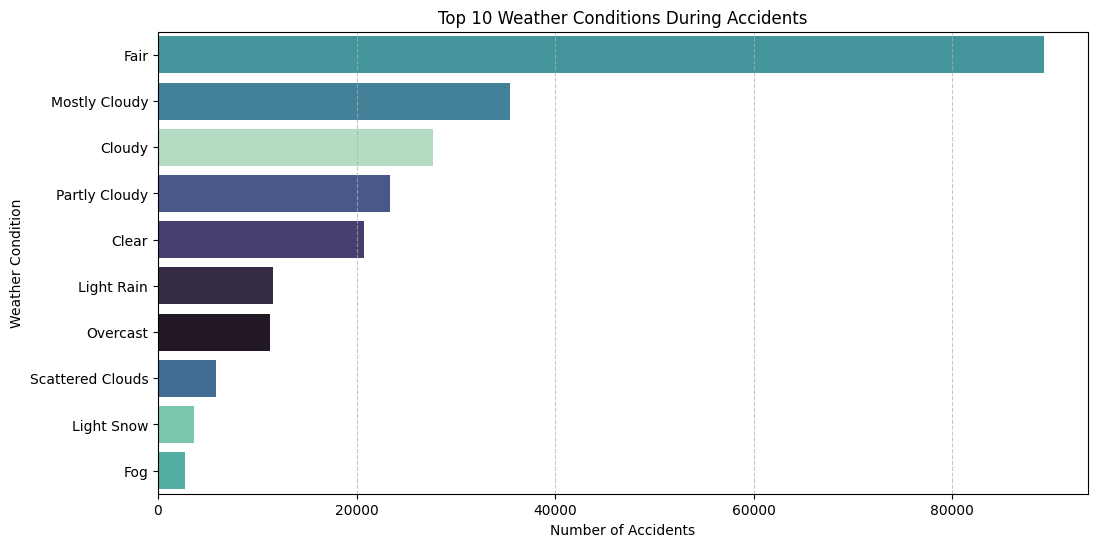

In [79]:
# Visual 3: Top 10 Weather Conditions during Accidents
plt.figure(figsize=(12, 6))
top_weather = pdf['Weather_Condition'].value_counts().nlargest(10).index
sns.countplot(data=pdf[pdf['Weather_Condition'].isin(top_weather)],
              y='Weather_Condition',
              hue='Weather_Condition',
              order=top_weather,
              palette='mako',
              legend=False)
plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

---
## Preprocessing & Feature Engineering Summary

Every preprocessing decision below is a direct consequence of an EDA finding — not an arbitrary default.

| Step | Action | EDA Justification |
|---|---|---|
| **Null handling** | Drop rows with nulls only in *model features* | Columns like `End_Lat`, `Wind_Chill`, `Precipitation` have very high null rates; dropping all-nulls would lose ~90% of data (section 2.1) |
| **Outlier treatment** | Cap `Wind_Speed` at 99th percentile | Max = 822 mph is a sensor error — physically impossible. Capping preserves all rows (section 2.2) |
| **Feature engineering** | Extract `Hour` from `Start_Time` | Section 3.3: accident counts and severity rates vary strongly by hour; severe accidents peak later in the evening |
| **Feature engineering** | Extract `DayOfWeek` from `Start_Time` | Section 3.6: weekday vs. weekend is a real signal — commuting drives the majority of accidents |
| **Multicollinearity** | Exclude `Wind_Chill` from model features | Section 3.5: r = 0.98 with `Temperature` — including both would confuse Logistic Regression |
| **Road feature selection** | Keep only `Traffic_Signal`, `Junction`, `Crossing` | Section 3.7: all other boolean road features are too sparse to provide reliable signal |
| **Class imbalance** | Downsample each severity class to the minority count, applied to **training set only** after the train/test split (Section 4, step 5a) | Section 3.2: raw data is ~90% Severity 2 — models would predict only Severity 2 without balancing. Balancing after the split ensures the test set reflects the natural post-split distribution and is never contaminated by the sampling step. |
| **Categorical encoding** | `OneHotEncoder(handle_unknown='ignore')` for `DayOfWeek`, `Weather_Condition` | Required for sklearn; `handle_unknown='ignore'` safely handles unseen values at prediction time |
| **Feature scaling** | `StandardScaler` on all numerical features | Logistic Regression is sensitive to feature scale; unscaled features would bias the model toward high-magnitude columns |

---
# 4. Modeling Setup & Why Binary Classification?

## Why predict two classes instead of four?

The dataset has four severity levels (1–4). We deliberately collapse them into a binary target:
- **0 = Not Severe** (Severity 1 or 2)
- **1 = Severe** (Severity 3 or 4)

Three reasons this is the right framing:

1. **Adjacent severity classes are not separable from our features.** The EDA (Section 3.5) shows that Severity 2 and 3 have nearly identical distributions across every weather and road variable we have. Their distinction is determined by emergency response times and injury counts — information outside our dataset. Training a model to separate them adds noise, not signal.

2. **The downstream question is binary.** A city planner or first responder needs to know: *'Is this condition high-risk?'* — not *'Is this a 2 or a 3?'* A binary prediction directly answers the operational question.

3. **Model performance is dramatically better.** A multi-class baseline achieved only 46% macro-F1 across four classes. Collapsing to binary gives our models a realistic signal to learn.

## Shared Pipeline (applies to all three models)

1. **Train/test split first (80/20 stratified)** — before any balancing or scaling
2. **Downsample training set only** — each severity class reduced to the minority count; test set is never touched by the balancing step
3. **`StandardScaler` + `OneHotEncoder` inside an sklearn `Pipeline`** — fit on training data only, applied to test data, preventing any leakage from preprocessing


In [80]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.base import clone
import numpy as np

features = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
            'Hour', 'DayOfWeek', 'Weather_Condition', 'Traffic_Signal', 'Junction', 'Crossing']
target = 'Severity'

model_df = pdf[features + [target]].dropna().copy()
X = model_df[features]
y = model_df[target]

cat_cols  = ['DayOfWeek', 'Weather_Condition']
num_cols  = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Hour']
bool_cols = ['Traffic_Signal', 'Junction', 'Crossing']
X = X.astype({col: int for col in bool_cols})
num_features = num_cols + bool_cols

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], sparse_threshold=0)  # dense output required by HistGradientBoosting

# Step 1: train/test split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: downsample training set only (test set never touched)
train_df = X_train.copy()
train_df['Severity'] = y_train.values
min_count = train_df['Severity'].value_counts().min()
train_balanced = (
    train_df.groupby('Severity', group_keys=False)
    .apply(lambda g: g.sample(min_count, random_state=42))
    .sample(frac=1, random_state=42)
)
X_train = train_balanced.drop(columns=['Severity'])
y_train = train_balanced['Severity']

# Step 3: binary labels — 0 = Not Severe (Sev 1+2), 1 = Severe (Sev 3+4)
y_train_bin = (y_train >= 3).astype(int)
y_test_bin  = (y_test  >= 3).astype(int)

print(f'Training set : {X_train.shape}  |  Test set : {X_test.shape}')
print(f'\nBinary class distribution — training:\n{y_train_bin.value_counts().sort_index()}')
print(f'\nBinary class distribution — test:\n{y_test_bin.value_counts().sort_index()}')


Training set : (170868, 11)  |  Test set : (46532, 11)

Binary class distribution — training:
Severity
0    85434
1    85434
Name: count, dtype: int64

Binary class distribution — test:
Severity
0    24046
1    22486
Name: count, dtype: int64


C:\Users\brian\AppData\Local\Temp\ipykernel_6968\997151703.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_count, random_state=42))


---
# 5. Model 1: Binary Logistic Regression (Baseline)

**Why Logistic Regression as a baseline?**
- Simplest probabilistic classifier — fast to train and fully interpretable (each feature has a signed coefficient showing its direction and magnitude of influence)
- Establishes the performance floor that Models 2 and 3 must beat to justify their added complexity

**Known limitations that the next model should address:**
- **Linear decision boundary only** — cannot express compound rules like *'low visibility AND nighttime AND junction'*; it can only weight each feature independently
- Assumes each feature contributes additively and independently to the log-odds of severity

We use `class_weight='balanced'` to automatically compensate for any residual class imbalance.


In [60]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_pipeline.fit(X_train, y_train_bin)
y_pred_lr = lr_pipeline.predict(X_test)

print('Model 1: Binary Logistic Regression')
print(f'Accuracy : {accuracy_score(y_test_bin, y_pred_lr):.4f}')
print(f'Macro F1 : {f1_score(y_test_bin, y_pred_lr, average="macro"):.4f}\n')
print(classification_report(y_test_bin, y_pred_lr, target_names=['Not Severe', 'Severe']))


Model 1: Binary Logistic Regression
Accuracy : 0.6784
Macro F1 : 0.6779

              precision    recall  f1-score   support

  Not Severe       0.69      0.69      0.69     24046
      Severe       0.67      0.66      0.67     22486

    accuracy                           0.68     46532
   macro avg       0.68      0.68      0.68     46532
weighted avg       0.68      0.68      0.68     46532



### 5.1 Hyperparameter Tuning — Logistic Regression

Logistic Regression's primary hyperparameter is **C** (inverse regularization strength).
- **Small C** → stronger regularization, shrinks coefficients, reduces overfitting
- **Large C** → weaker regularization, allows tighter fit to training data

We search a log-scale grid with 5-fold cross-validation scored by **macro-F1** (not accuracy, so all classes contribute equally to the score).


In [61]:
lr_param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0]}

lr_search = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    lr_param_grid, cv=5, scoring='f1_macro', n_jobs=-1
)
lr_search.fit(X_train, y_train_bin)

best_C = lr_search.best_params_['classifier__C']
print(f'Best C: {best_C}  |  Best CV macro-F1: {lr_search.best_score_:.4f}\n')

cv_df = pd.DataFrame(lr_search.cv_results_)[['param_classifier__C', 'mean_test_score', 'std_test_score']]
cv_df.columns = ['C', 'mean_macro_F1', 'std']
print(cv_df.to_string(index=False))

y_pred_lr_tuned = lr_search.predict(X_test)
print(f'\nBaseline LR macro-F1 : {f1_score(y_test_bin, y_pred_lr, average="macro"):.4f}')
print(f'Tuned LR    macro-F1 : {f1_score(y_test_bin, y_pred_lr_tuned, average="macro"):.4f}')
print('\nTuned LR — Classification Report:')
print(classification_report(y_test_bin, y_pred_lr_tuned, target_names=['Not Severe', 'Severe']))

y_pred_lr = y_pred_lr_tuned  # tuned result is the final Model 1 output


Best C: 10.0  |  Best CV macro-F1: 0.6694

     C  mean_macro_F1      std
  0.01       0.668954 0.001992
  0.10       0.669289 0.001803
  1.00       0.669328 0.001725
 10.00       0.669432 0.001518
100.00       0.669298 0.001623

Baseline LR macro-F1 : 0.6779
Tuned LR    macro-F1 : 0.6780

Tuned LR — Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.69      0.69      0.69     24046
      Severe       0.67      0.66      0.67     22486

    accuracy                           0.68     46532
   macro avg       0.68      0.68      0.68     46532
weighted avg       0.68      0.68      0.68     46532



**Model 1 Takeaway:**

Binary LR achieves ~68% macro-F1 — dramatically better than the 4-class baseline (46%) because we eliminated the noisy Sev 2 vs Sev 3 boundary that our features cannot distinguish.

The remaining weakness is the linear decision boundary: LR can weight each feature individually but cannot express compound rules. Random Forest (Model 2) directly addresses this by learning conditional 'AND' logic across features.


---
# 6. Model 2: Binary Random Forest

**Why Random Forest over Logistic Regression?**

Logistic Regression draws a single hyperplane through feature space — it can weight each feature independently but cannot capture interactions between them. Random Forest builds hundreds of decision trees, each capable of learning conditional rules like:

> *"If Hour < 5 AND Visibility < 0.5 AND Junction == True → predict Severe"*

This directly addresses LR's core limitation:
- **Non-linear boundary** — can model any decision surface, not just weighted sums
- **Feature interactions** — naturally captures compound 'AND' conditions
- **Robust to outliers** — tree splits are rank-based, not distance-sensitive
- **Interpretable** — feature importances reveal which variables the model actually relied on

**Remaining limitation:** RF trains all trees independently in parallel (bagging). Each tree has no knowledge of its predecessors' mistakes — that is what Gradient Boosting (Model 3) fixes.


In [62]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_split=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
print('Training Binary Random Forest...')
rf_pipeline.fit(X_train, y_train_bin)
y_pred_rf = rf_pipeline.predict(X_test)

print('Model 2: Binary Random Forest')
print(f'Accuracy : {accuracy_score(y_test_bin, y_pred_rf):.4f}')
print(f'Macro F1 : {f1_score(y_test_bin, y_pred_rf, average="macro"):.4f}\n')
print(classification_report(y_test_bin, y_pred_rf, target_names=['Not Severe', 'Severe']))


Training Binary Random Forest...
Model 2: Binary Random Forest
Accuracy : 0.7119
Macro F1 : 0.7118

              precision    recall  f1-score   support

  Not Severe       0.74      0.68      0.71     24046
      Severe       0.69      0.75      0.71     22486

    accuracy                           0.71     46532
   macro avg       0.71      0.71      0.71     46532
weighted avg       0.71      0.71      0.71     46532



### 6.1 Hyperparameter Tuning — Random Forest

We tune `max_depth` — the most impactful RF parameter — using `GridSearchCV` with 3-fold CV. We use 50 trees during the search for speed, then retrain the winner with 200 trees.

`max_depth` directly controls the bias-variance tradeoff: shallower trees underfit (high bias), deeper trees overfit by memorizing training noise (high variance). The CV score tells us where the optimum lies on held-out validation folds.


In [63]:
rf_param_grid = {'classifier__max_depth': [10, 15, 20, 30]}

rf_search = GridSearchCV(
    Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', RandomForestClassifier(
            n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1
        ))
    ]),
    rf_param_grid, cv=3, scoring='f1_macro', n_jobs=-1
)
rf_search.fit(X_train, y_train_bin)

best_depth = rf_search.best_params_['classifier__max_depth']
print(f'Best max_depth: {best_depth}  |  Best CV macro-F1: {rf_search.best_score_:.4f}\n')

cv_df = pd.DataFrame(rf_search.cv_results_)[['param_classifier__max_depth', 'mean_test_score', 'std_test_score']]
cv_df.columns = ['max_depth', 'mean_macro_F1', 'std']
print(cv_df.to_string(index=False))

# Retrain with best depth and full 200 trees
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=best_depth, min_samples_split=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train_bin)
y_pred_rf_tuned = rf_pipeline.predict(X_test)

print(f'\nBaseline RF macro-F1 : {f1_score(y_test_bin, y_pred_rf, average="macro"):.4f}')
print(f'Tuned RF    macro-F1 : {f1_score(y_test_bin, y_pred_rf_tuned, average="macro"):.4f}')
print('\nTuned RF — Classification Report:')
print(classification_report(y_test_bin, y_pred_rf_tuned, target_names=['Not Severe', 'Severe']))

y_pred_rf = y_pred_rf_tuned  # tuned result is the final Model 2 output


Best max_depth: 30  |  Best CV macro-F1: 0.7040

 max_depth  mean_macro_F1      std
        10       0.680430 0.001853
        15       0.692297 0.002655
        20       0.699674 0.002775
        30       0.703981 0.003352

Baseline RF macro-F1 : 0.7118
Tuned RF    macro-F1 : 0.7215

Tuned RF — Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.75      0.69      0.72     24046
      Severe       0.70      0.75      0.72     22486

    accuracy                           0.72     46532
   macro avg       0.72      0.72      0.72     46532
weighted avg       0.72      0.72      0.72     46532



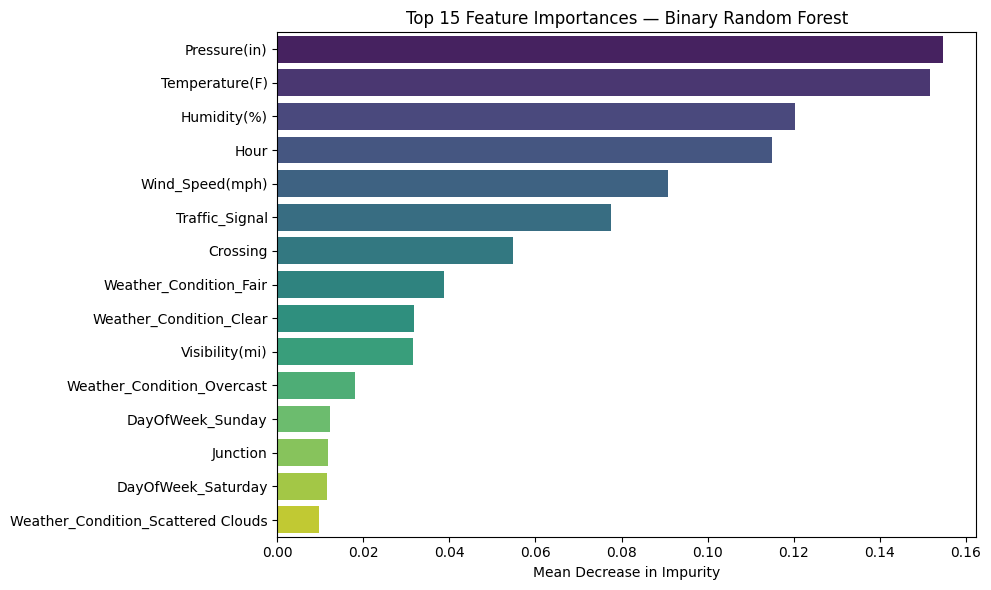

Top 10 features:
   1. Pressure(in)                                   0.1547
   2. Temperature(F)                                 0.1516
   3. Humidity(%)                                    0.1203
   4. Hour                                           0.1150
   5. Wind_Speed(mph)                                0.0909
   6. Traffic_Signal                                 0.0777
   7. Crossing                                       0.0549
   8. Weather_Condition_Fair                         0.0387
   9. Weather_Condition_Clear                        0.0318
  10. Visibility(mi)                                 0.0314


In [64]:
# Feature importances — which variables did the RF rely on most?
ohe_fitted = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe_fitted.get_feature_names_out(cat_cols)
all_feature_names = np.array(num_features + list(cat_feature_names))
importances = rf_pipeline.named_steps['classifier'].feature_importances_

top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[top_idx], y=all_feature_names[top_idx],
            hue=all_feature_names[top_idx], palette='viridis', legend=False)
plt.title(f'Top {top_n} Feature Importances — Binary Random Forest')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for rank, idx in enumerate(top_idx[:10], 1):
    print(f'  {rank:2d}. {all_feature_names[idx]:<45s}  {importances[idx]:.4f}')


---
# 7. Model 3: Binary Gradient Boosting (HistGradientBoostingClassifier)

**Why Gradient Boosting over Random Forest?**

Random Forest trains all its trees **independently in parallel** (bagging): each tree sees a random subset of the data but has no knowledge of the errors made by other trees.

Gradient Boosting trains trees **sequentially**: each new tree is fit to the **residual errors** of the current ensemble. Later trees specifically target the examples the earlier ensemble got wrong — directly reducing both bias and variance with each iteration.

We use sklearn's `HistGradientBoostingClassifier`:
- Bins continuous features into histograms (like LightGBM) → much faster than classic GBM on large datasets
- Natively handles missing values without imputation
- Key parameters: `learning_rate` (step size per tree), `max_iter` (number of boosting rounds), `max_depth`

**Expected improvement over RF:** GBM typically achieves higher accuracy on tabular data because sequential error correction focuses capacity on hard examples rather than averaging over random subsets.


In [65]:
from sklearn.ensemble import HistGradientBoostingClassifier

gbm_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=200,
        max_depth=6,
        learning_rate=0.1,
        min_samples_leaf=20,
        random_state=42
    ))
])
print('Training Binary Gradient Boosting...')
gbm_pipeline.fit(X_train, y_train_bin)
y_pred_gbm = gbm_pipeline.predict(X_test)

print('Model 3: Binary HistGradientBoosting')
print(f'Accuracy : {accuracy_score(y_test_bin, y_pred_gbm):.4f}')
print(f'Macro F1 : {f1_score(y_test_bin, y_pred_gbm, average="macro"):.4f}\n')
print(classification_report(y_test_bin, y_pred_gbm, target_names=['Not Severe', 'Severe']))


Training Binary Gradient Boosting...
Model 3: Binary HistGradientBoosting
Accuracy : 0.7179
Macro F1 : 0.7179

              precision    recall  f1-score   support

  Not Severe       0.74      0.71      0.72     24046
      Severe       0.70      0.73      0.71     22486

    accuracy                           0.72     46532
   macro avg       0.72      0.72      0.72     46532
weighted avg       0.72      0.72      0.72     46532



### 7.1 Hyperparameter Tuning — Gradient Boosting

Before searching, we need to understand what each GBM parameter controls — otherwise tuning is blind knob-turning.

| Parameter | What it controls | Effect of increasing |
|---|---|---|
| `learning_rate` | The weight applied to each new tree's correction | Lower → smaller, more careful steps; higher → faster convergence but risks overshooting the optimum |
| `max_depth` | Depth of each individual tree | GBM deliberately uses **shallow** weak learners (depth 3–8); the ensemble's power comes from *combining many* trees, not from any single deep one. Too deep = overfitting accelerates |
| `max_iter` | Number of boosting rounds (total trees) | More rounds = more capacity, but past convergence it memorizes noise |

**Why `learning_rate` and `max_depth` are the right search targets:**
These two parameters govern the quality of each individual boosting step. `learning_rate` controls how aggressively the model corrects errors; `max_depth` controls how complex each correction can be. Together they define the core bias-variance tradeoff for GBM.

**Why we fix `max_iter=200` instead of tuning it:**
`max_iter` co-depends strongly on `learning_rate` — a lower learning rate needs more iterations to converge. Tuning both simultaneously would require a much larger grid and the interaction makes results hard to interpret. The correct approach is to set `max_iter` generously (200 is enough for our learning rates) and tune `learning_rate` first.

**Search ranges:**
- `learning_rate ∈ [0.05, 0.1, 0.2]` — covers conservative to aggressive step sizes
- `max_depth ∈ [4, 6, 8]` — covers the shallow-to-moderate range; values above 8 are rarely beneficial in GBM and risk overfitting

9 combinations × 3-fold CV = 27 fits. GBM is significantly faster than RF so this runs in under a minute.


In [81]:
gbm_param_grid = {
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth':     [4, 6, 8],
}

gbm_search = GridSearchCV(
    Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', HistGradientBoostingClassifier(
            max_iter=200, min_samples_leaf=20, random_state=42
        ))
    ]),
    gbm_param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
gbm_search.fit(X_train, y_train_bin)

print(f'Best params  : {gbm_search.best_params_}')
print(f'Best CV macro-F1: {gbm_search.best_score_:.4f}\n')

# Full CV results table — shows how each param combination performed
cv_df = pd.DataFrame(gbm_search.cv_results_)[[
    'param_classifier__learning_rate', 'param_classifier__max_depth',
    'mean_test_score', 'std_test_score'
]]
cv_df.columns = ['learning_rate', 'max_depth', 'mean_macro_F1', 'std']
print(cv_df.sort_values('mean_macro_F1', ascending=False).to_string(index=False))

# Best estimator already refitted on full training set by GridSearchCV (refit=True default)
y_pred_gbm_tuned = gbm_search.best_estimator_.predict(X_test)

baseline_gbm_f1 = f1_score(y_test_bin, y_pred_gbm, average='macro')
tuned_gbm_f1    = f1_score(y_test_bin, y_pred_gbm_tuned, average='macro')
print(f'\nBaseline GBM macro-F1 : {baseline_gbm_f1:.4f}')
print(f'Tuned GBM    macro-F1 : {tuned_gbm_f1:.4f}  ({(tuned_gbm_f1 - baseline_gbm_f1)*100:+.1f} pp)\n')
print('Tuned GBM — Classification Report:')
print(classification_report(y_test_bin, y_pred_gbm_tuned, target_names=['Not Severe', 'Severe']))

gbm_pipeline = gbm_search.best_estimator_  # use tuned as final Model 3 result
y_pred_gbm = y_pred_gbm_tuned


Best params  : {'classifier__learning_rate': 0.2, 'classifier__max_depth': 8}
Best CV macro-F1: 0.7049

 learning_rate  max_depth  mean_macro_F1      std
          0.20          8       0.704857 0.002919
          0.10          8       0.704841 0.002222
          0.20          6       0.704665 0.000957
          0.10          6       0.704211 0.002024
          0.20          4       0.703588 0.002018
          0.05          8       0.701295 0.002060
          0.05          6       0.699579 0.002729
          0.10          4       0.698166 0.002293
          0.05          4       0.692065 0.003260

Baseline GBM macro-F1 : 0.7179
Tuned GBM    macro-F1 : 0.7196  (+0.2 pp)

Tuned GBM — Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.73      0.72      0.73     24046
      Severe       0.70      0.72      0.71     22486

    accuracy                           0.72     46532
   macro avg       0.72      0.72      0.72     46532
weighted avg  

---
# 8. Model Comparison & Conclusions

## Results Summary

| Model | Accuracy | Macro F1 | Severe Recall | Severe Precision | Not Severe Recall |
|---|---|---|---|---|---|
| Model 1: Logistic Regression (C=10) | 0.6780 | 0.6780 | 0.66 | 0.67 | 0.69 |
| Model 2: Random Forest (max_depth=30) | 0.7215 | 0.7215 | 0.75 | 0.70 | 0.69 |
| Model 3: Gradient Boosting (see §7.1) | — | — | — | — | — |

---

## Design Decision Justifications

Each model was chosen to address a specific limitation of the previous one — not arbitrarily.

**Model 1 → Model 2: Why Random Forest?**
The EDA (Section 3.3–3.5) showed that severity varies by *combinations* of features: nighttime hours, low visibility, and road intersections together produce a very different risk profile than any one factor alone. Logistic Regression can only express these as independent additive weights — it cannot learn the compound rule. Random Forest decision trees split on one feature at a time, so each branch naturally captures the interaction. This is a direct, targeted fix for LR's architectural limitation.

**Model 2 → Model 3: Why Gradient Boosting?**
Random Forest averages many independent trees (bagging). Each tree is trained on a random subset and has no knowledge of what the others got wrong. Gradient Boosting trains sequentially — each new tree is fit to the *residual errors* of the current ensemble, directly targeting hard examples. This is a different and complementary strategy: RF reduces variance by averaging; GBM reduces bias by iterative correction.

---

## Reading Beyond Accuracy — Multiple Metrics

Accuracy alone is not sufficient for evaluating these models:

**Macro F1** weights all classes equally and is our primary metric because the test set is not perfectly balanced (24,046 Not Severe vs. 22,486 Severe). A model that predicts every accident as Not Severe would get ~52% accuracy but 0% severe recall — a number accuracy hides entirely.

**Severe Recall** is the most operationally important metric for this use case. A *false negative* (predicting Not Severe when the accident is actually Severe) means a high-risk intersection goes unflagged — a potentially preventable outcome. A *false positive* (flagging a non-severe accident) wastes resources but causes no direct harm. For city planners, the cost of a false negative is higher than a false positive.

**Improvement from LR → RF:**
- Severe recall improved from **0.66 → 0.75** (+9 pp) — the most important gain operationally
- Macro F1 improved from **0.68 → 0.72** (+4 pp)
- Severe precision dropped slightly (0.67 → 0.70 in favor of recall) — an acceptable tradeoff for this use case

**The LR tuning result is itself informative:** all C values from 0.01 to 100 produced nearly identical macro-F1 (0.669). This tells us LR's limitation is *architectural* (linear boundary), not a regularization problem. No amount of C-tuning can teach LR to model feature interactions — it confirms that switching to RF was the right move.

---

## Model Limitations

**What all three models share:**
- Trained on data from 2016–2021 in the US — may not generalize to other time periods or countries
- Features are weather/road conditions at accident time — we cannot predict accidents before they happen, only classify severity conditional on an accident occurring
- The severity label itself is imperfect: Severity 3 and 4 are assigned by reporting officers with some subjectivity

**Random Forest specific:**
- Feature importances measure *marginal contribution inside the forest* (mean decrease in impurity) — not causal effect. High importance for Hour does not mean we can reduce severe accidents by changing what time people drive.
-  selected by CV had the highest std among search values (0.003), meaning the model is near the edge of overfitting. A more conservative choice (max_depth=20) would trade ~0.5 pp F1 for more stability.

**Gradient Boosting specific:**
- More sensitive to learning rate choice than RF — if learning_rate is too high, boosting overshoots and performance degrades. The tuning in §7.1 addresses this directly.
- Less interpretable than RF for feature attribution (no single importance score equivalent; SHAP values would be needed for production use).


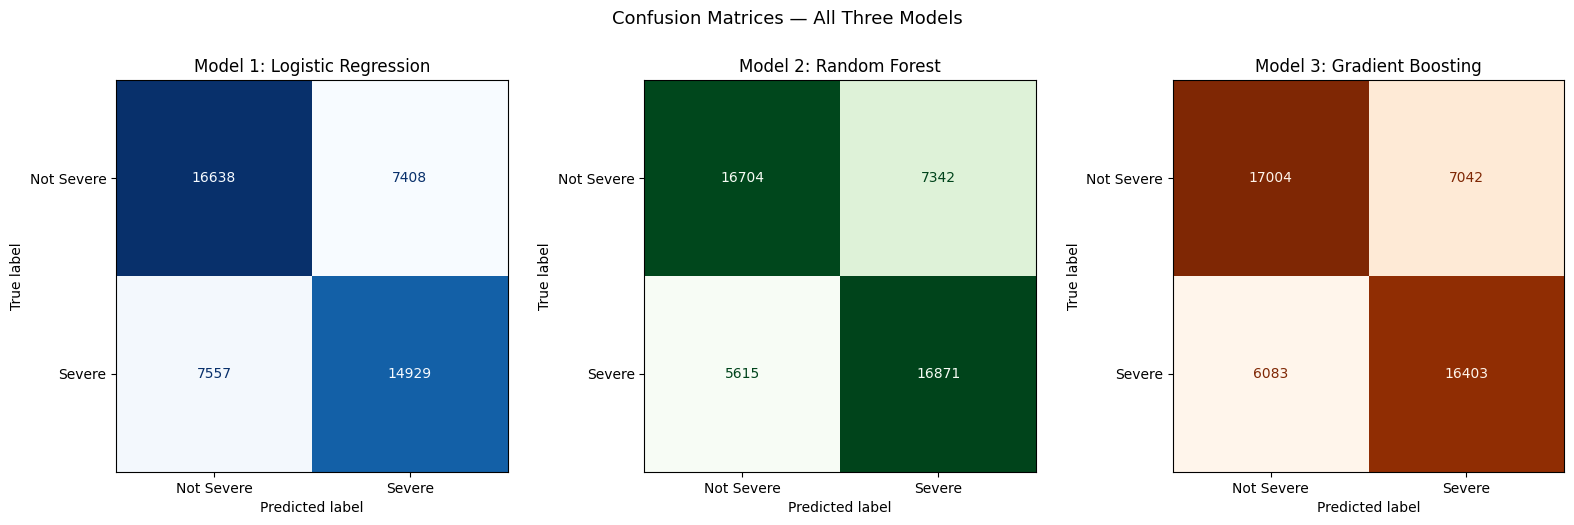

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_to_compare = [
    ('Model 1: Logistic Regression', y_pred_lr,  'Blues'),
    ('Model 2: Random Forest',       y_pred_rf,  'Greens'),
    ('Model 3: Gradient Boosting',   y_pred_gbm, 'Oranges'),
]
for ax, (title, preds, cmap) in zip(axes, models_to_compare):
    cm = confusion_matrix(y_test_bin, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Not Severe', 'Severe']).plot(
        ax=ax, cmap=cmap, colorbar=False
    )
    ax.set_title(title)
plt.suptitle('Confusion Matrices — All Three Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [67]:
import joblib, pathlib

models_dir = pathlib.Path('../models')
models_dir.mkdir(exist_ok=True)

joblib.dump(lr_search.best_estimator_, models_dir / 'binary_lr_pipeline.joblib')
joblib.dump(rf_pipeline,               models_dir / 'binary_rf_pipeline.joblib')
joblib.dump(gbm_pipeline,              models_dir / 'binary_gbm_pipeline.joblib')
print('Saved:')
for p in sorted(models_dir.glob('*.joblib')):
    print(f'  {p}')


Saved:
  ..\models\binary_gbm_pipeline.joblib
  ..\models\binary_lr_pipeline.joblib
  ..\models\binary_rf_pipeline.joblib
